In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/medical-insurance-cost-prediction-dataset/insurance.csv


1.Importing Libraries
Load essential Python libraries for data handling, visualization, and machine learning.  
These tools help in cleaning data, creating visual insights, and building predictive models efficiently.


In [2]:
# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="pastel")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# Style consistency
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
# Load dataset
data_path = '/kaggle/input/medical-insurance-cost-prediction-dataset/insurance.csv'
df = pd.read_csv(data_path)

# Overview
print("✅ Dataset Loaded Successfully!")
display(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

✅ Dataset Loaded Successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
print("Summary Statistics:")
display(df.describe(include='all'))

print("\nUnique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Summary Statistics:


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515



Unique Values per Column:
age: 47
sex: 2
bmi: 548
children: 6
smoker: 2
region: 4
charges: 1337


In [5]:
# Convert categorical variables to category type
categorical_columns = ['sex', 'smoker', 'region']
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded DataFrame:")
display(df_encoded.head())

Encoded DataFrame:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


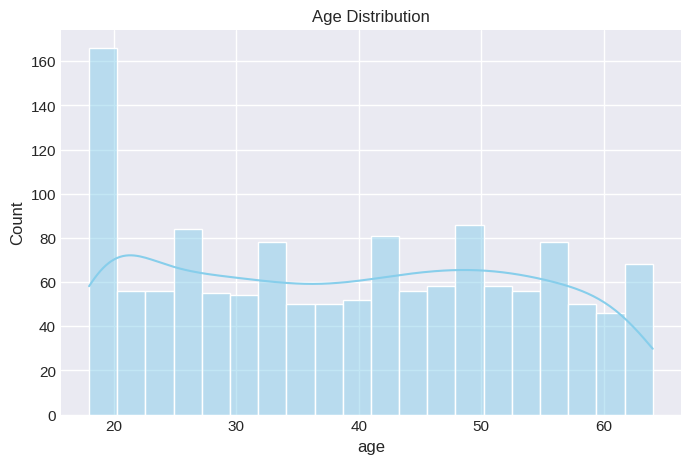

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=20, color='skyblue')
plt.title("Age Distribution")
plt.show()

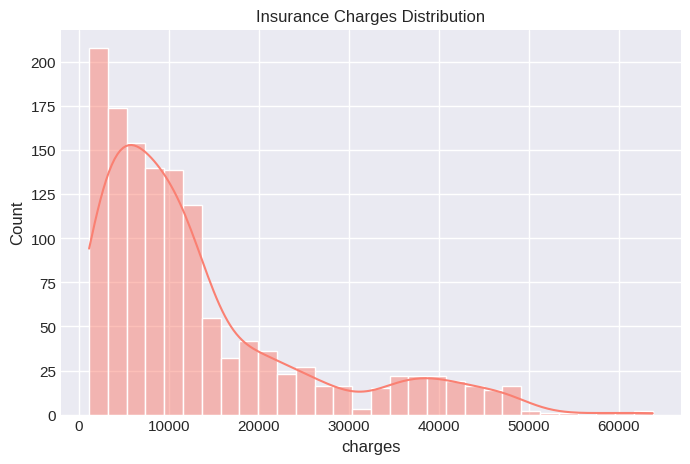

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, color='salmon')
plt.title("Insurance Charges Distribution")
plt.show()

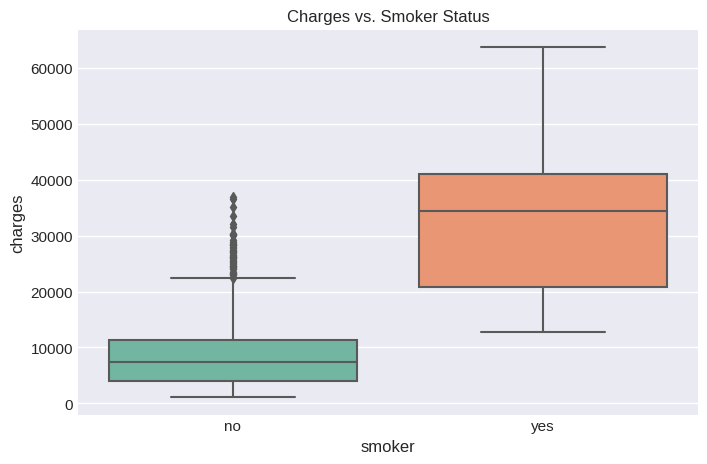

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')
plt.title("Charges vs. Smoker Status")
plt.show()

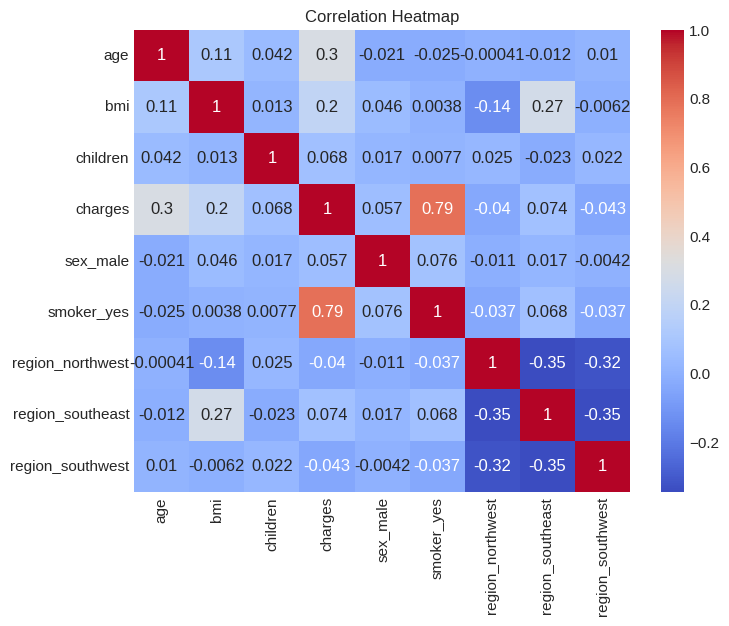

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# BMI Categories
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Healthy', 'Overweight', 'Obese'])
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)

# Encoding again with new feature
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"Linear Regression Performance:\nR² = {r2_lr:.3f}\nMAE = {mae_lr:.2f}\nRMSE = {rmse_lr:.2f}")

Linear Regression Performance:
R² = 0.781
MAE = 4311.33
RMSE = 5825.28


In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
display(results_df)

,Model,R2,MAE,RMSE
4,Gradient Boosting,0.873582,2485.945930,4430.149173
3,Random Forest,0.865799,2567.671530,4564.480192
1,Ridge Regression,0.781667,4308.056227,5822.025014
2,Lasso Regression,0.781424,4311.307558,5825.256006
0,Linear Regression,0.781423,4311.331174,5825.276600


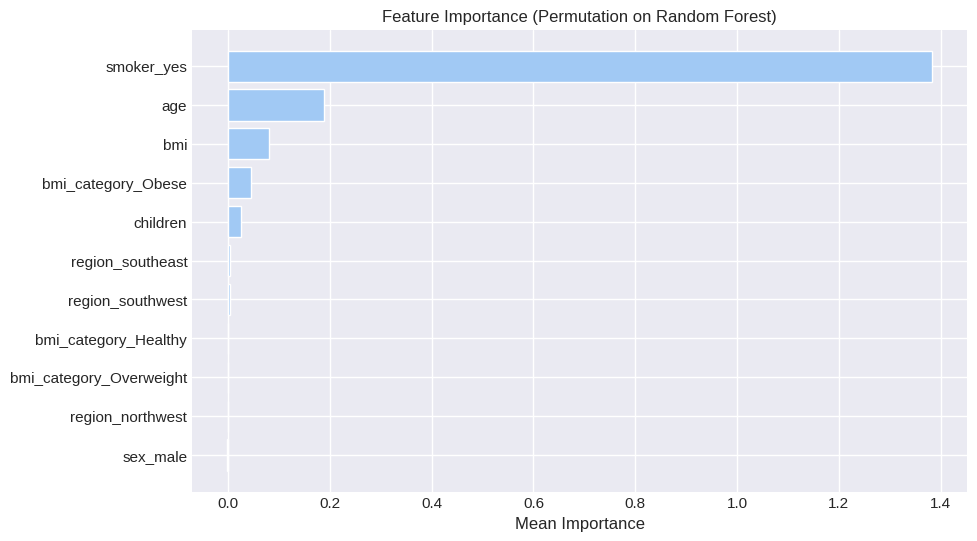

In [13]:
best_model = RandomForestRegressor(n_estimators=200, random_state=42)
best_model.fit(X_train_scaled, y_train)

perm_importance = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title('Feature Importance (Permutation on Random Forest)')
plt.xlabel('Mean Importance')
plt.show()